# Sentinel-1 GRD Product: Rectification

In [1]:
import os

import rioxarray
import pystac_client
import numpy as np
import xarray as xr
from xcube.core.store import new_data_store
from xcube_resampling.gridmapping import GridMapping
from xcube_resampling import affine_transform_dataset
from xcube_resampling import rectify_dataset
from xcube_resampling.gridmapping import GridMapping
from dask.distributed import Client, LocalCluster
import xrspatial
import matplotlib.pyplot as plt
from resample import resample_reg2irreg

xr.set_options(display_expand_attrs=False)

In [2]:
cluster = LocalCluster(
    n_workers=4,
    threads_per_worker=1,
    memory_limit="8GB",
    dashboard_address="8787",
)
client = Client(cluster)
client.dashboard_link

'http://127.0.0.1:8787/status'

2026-04-02 17:53:37,558 - tornado.application - ERROR - Uncaught exception GET /status/ws (127.0.0.1)
HTTPServerRequest(protocol='http', host='127.0.0.1:8787', method='GET', uri='/status/ws', version='HTTP/1.1', remote_ip='127.0.0.1')
Traceback (most recent call last):
  File "/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/tornado/websocket.py", line 938, in _accept_connection
    open_result = handler.open(*handler.open_args, **handler.open_kwargs)
  File "/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/tornado/web.py", line 3301, in wrapper
    return method(self, *args, **kwargs)
  File "/home/konstantin/micromamba/envs/xcube-eopf/lib/python3.13/site-packages/bokeh/server/views/ws.py", line 149, in open
    raise ProtocolError("Token is expired. Configure the app with a larger value for --session-token-expiration if necessary")
bokeh.protocol.exceptions.ProtocolError: Token is expired. Configure the app with a larger value for --ses

## Load Sentinel-1 GRD product

In [3]:
path = (
    "data/S1C_IW_GRDH_1SDV_20260331T043117_20260331T043142_007003_00E2E3_7002.zarr"
)

In [4]:
%%time
dt = xr.open_datatree(path, engine="zarr", chunks={})

CPU times: user 268 ms, sys: 18.4 ms, total: 286 ms
Wall time: 275 ms


In [5]:
%%time
group_VH = [x for x in dt.children if "VH" in x][0]
grd = dt[group_VH].measurements.to_dataset().rename({"grd": "vh"})
group_VV = [x for x in dt.children if "VV" in x][0]
grd["vv"] = dt[group_VV].measurements.to_dataset().grd
grd

CPU times: user 3.19 ms, sys: 46 μs, total: 3.24 ms
Wall time: 2.51 ms


<xarray.Dataset> Size: 2GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) int64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    vh            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) uint16 868MB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

CPU times: user 1.91 s, sys: 183 ms, total: 2.09 s
Wall time: 3.85 s


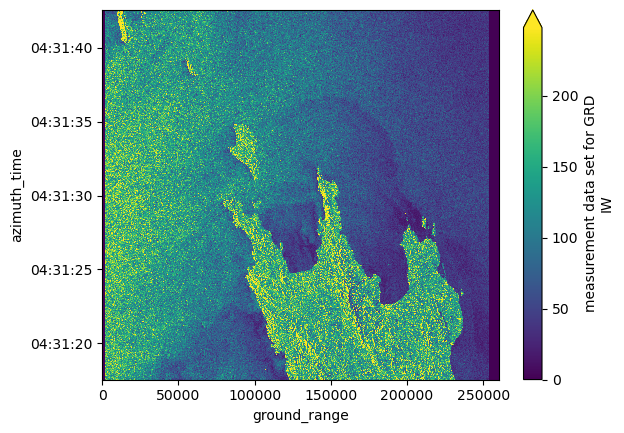

In [6]:
%%time
grd.vv[::20, ::20].plot(robust=True)

## Apply radiometric calibration

In [7]:
%%time
beta_lut = dt[group_VH].quality.calibration.to_dataset()["beta_nought"]
beta_lut

CPU times: user 7.06 ms, sys: 61 μs, total: 7.12 ms
Wall time: 5.57 ms


<xarray.DataArray 'beta_nought' (azimuth_time: 27, ground_range: 651)> Size: 70kB
dask.array<open_dataset-beta_nought, shape=(27, 651), dtype=float32, chunksize=(27, 651), chunktype=numpy.ndarray>
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 216B 2026-03-31T04:31:17.5659...
    line          (azimuth_time) int32 108B dask.array<chunksize=(27,), meta=np.ndarray>
  * ground_range  (ground_range) float64 5kB 0.0 400.0 ... 2.596e+05 2.6e+05
    pixel         (ground_range) int32 3kB dask.array<chunksize=(651,), meta=np.ndarray>
Attributes: (3)

In [8]:
%%time
beta_lut_interp = beta_lut.interp(ground_range=grd.ground_range).chunk(dict(ground_range=2048))
beta_lut_interp = beta_lut_interp.interp(azimuth_time=grd.azimuth_time).chunk(dict(azimuth_time=2048))
beta0 = (grd / beta_lut_interp)**2
beta0

CPU times: user 874 ms, sys: 103 ms, total: 977 ms
Wall time: 1.5 s


<xarray.Dataset> Size: 3GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB 0 1 2 3 ... 25997 25998 25999 26000
Data variables:
    vh            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (3)

CPU times: user 8.43 s, sys: 1.02 s, total: 9.45 s
Wall time: 13.6 s


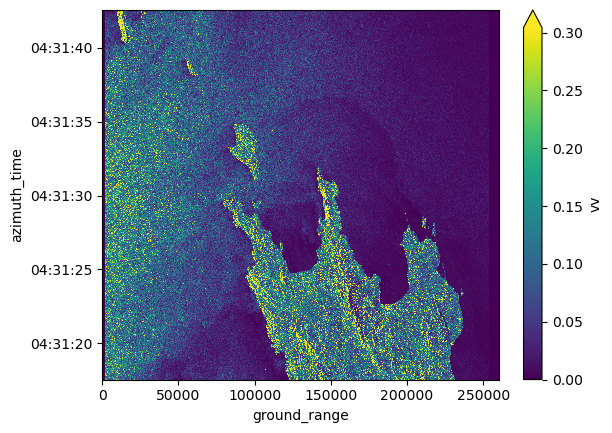

In [9]:
%%time
beta0.vv[::20, ::20].plot(robust=True)

## Add geolocation information

In [10]:
%%time
gcps = dt[group_VH].conditions.gcp.to_dataset()
gcps = gcps[["latitude", "longitude", "incidence_angle"]]
if gcps.longitude[0, 1] < gcps.longitude[0, 0]:
    gcps = gcps.isel(ground_range=slice(None, None, -1))
gcps

CPU times: user 154 ms, sys: 30 ms, total: 184 ms
Wall time: 209 ms


<xarray.Dataset> Size: 5kB
Dimensions:          (azimuth_time: 10, ground_range: 21)
Coordinates:
  * azimuth_time     (azimuth_time) datetime64[ns] 80B 2026-03-31T04:31:17.56...
    line             (azimuth_time) int32 40B dask.array<chunksize=(10,), meta=np.ndarray>
  * ground_range     (ground_range) float64 168B 2.6e+05 2.47e+05 ... 0.0
    pixel            (ground_range) int32 84B dask.array<chunksize=(21,), meta=np.ndarray>
Data variables:
    latitude         (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    longitude        (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>
    incidence_angle  (azimuth_time, ground_range) float64 2kB dask.array<chunksize=(10, 21), meta=np.ndarray>

In [11]:
%%time
gcps_interp = gcps.interp(ground_range=grd.ground_range).chunk(dict(ground_range=2048))
gcps_interp = gcps_interp.interp(azimuth_time=grd.azimuth_time).chunk(dict(azimuth_time=2048))
gcps_interp

CPU times: user 85.9 ms, sys: 9.2 ms, total: 95.1 ms
Wall time: 85 ms


<xarray.Dataset> Size: 10GB
Dimensions:          (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time     (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17....
    line             (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range     (ground_range) float64 208kB 0.0 10.0 ... 2.6e+05 2.6e+05
    pixel            (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    latitude         (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    longitude        (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    incidence_angle  (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

## Get DEM, slope and aspect (precomputed)

In [12]:
%%time
dem = xr.open_dataset("data/dem.zarr", chunks={})
dem = dem.assign_coords({"spatial_ref": dem.spatial_ref})
dem = dem[["aspect", "slope"]]
dem

CPU times: user 35.1 ms, sys: 9.03 ms, total: 44.1 ms
Wall time: 42.2 ms


<xarray.Dataset> Size: 1GB
Dimensions:      (lat: 10800, lon: 14400)
Coordinates:
  * lat          (lat) float64 86kB 38.0 38.0 38.0 38.0 ... 35.0 35.0 35.0 35.0
  * lon          (lon) float64 115kB 21.0 21.0 21.0 21.0 ... 25.0 25.0 25.0 25.0
    spatial_ref  int64 8B ...
Data variables:
    aspect       (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
    slope        (lat, lon) float32 622MB dask.array<chunksize=(3600, 3600), meta=np.ndarray>
Attributes: (1)

## Interpolate slope and aspect

In [13]:
%%time
target_gm = GridMapping.from_coords(gcps_interp.longitude, gcps_interp.latitude, "epsg:4326")
target_gm

CPU times: user 1.08 s, sys: 129 ms, total: 1.21 s
Wall time: 2.41 s


class: **Coords2DGridMapping**
* is_regular: False
* is_j_axis_up: False
* is_lon_360: False
* crs: epsg:4326
* xy_res: (0.000109922, 9.00037e-05)  _estimated_
* xy_bbox: (21.0518211, 35.52715, 24.2434975, 37.4372932)
* ij_bbox: (0, 0, 26001, 16700)
* xy_dim_names: ('ground_range', 'azimuth_time')
* xy_var_names: ('longitude', 'latitude')
* size: (26001, 16700)
* tile_size: (2048, 2048)

In [14]:
%%time
asslop_interp = resample_reg2irreg(dem, target_gm)
asslop_interp

CPU times: user 11.3 s, sys: 1.32 s, total: 12.6 s
Wall time: 20 s


<xarray.Dataset> Size: 10GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
    longitude     (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    spatial_ref   int64 8B 0
Data variables:
    aspect        (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    slope         (azimuth_time, ground_range) float32 2GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (1)

## Calculate azimuth angle

In [15]:
%%time
lat_rad = np.deg2rad(gcps_interp.latitude)

dy = np.gradient(gcps_interp.latitude.data, axis=0)          # degrees
dx = np.gradient(gcps_interp.longitude.data, axis=1) * np.cos(lat_rad)

gcps_interp["viewing_azimuth"] = np.arctan2(dx, dy) + np.pi / 2
gcps_interp

CPU times: user 13.8 ms, sys: 960 μs, total: 14.7 ms
Wall time: 13.6 ms


<xarray.Dataset> Size: 14GB
Dimensions:          (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time     (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17....
    line             (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range     (ground_range) float64 208kB 0.0 10.0 ... 2.6e+05 2.6e+05
    pixel            (ground_range) float64 208kB dask.array<chunksize=(2048,), meta=np.ndarray>
Data variables:
    latitude         (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    longitude        (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    incidence_angle  (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    viewing_azimuth  (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>

## Calcualte gamma nought

In [20]:
%%time
theta_i = np.deg2rad(gcps_interp.incidence_angle)
phi_i = gcps_interp.viewing_azimuth
aspect_rad = np.deg2rad(asslop_interp.aspect)
slope_rad = np.deg2rad(asslop_interp.slope)
cos_theta_lia = (
    np.cos(theta_i) * np.cos(slope_rad) +
    np.sin(theta_i) * np.sin(slope_rad) * np.cos(phi_i - aspect_rad)
)

gamma0 = beta0 / cos_theta_lia
gamma0

CPU times: user 260 ms, sys: 25 ms, total: 285 ms
Wall time: 300 ms


<xarray.Dataset> Size: 14GB
Dimensions:       (azimuth_time: 16700, ground_range: 26001)
Coordinates:
  * azimuth_time  (azimuth_time) datetime64[ns] 134kB 2026-03-31T04:31:17.565...
    line          (azimuth_time) float64 134kB dask.array<chunksize=(2048,), meta=np.ndarray>
  * ground_range  (ground_range) float64 208kB 0.0 10.0 20.0 ... 2.6e+05 2.6e+05
    pixel         (ground_range) int64 208kB 0 1 2 3 ... 25997 25998 25999 26000
    longitude     (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    latitude      (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    spatial_ref   int64 8B 0
Data variables:
    vh            (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
    vv            (azimuth_time, ground_range) float64 3GB dask.array<chunksize=(2048, 2048), meta=np.ndarray>
Attributes: (3)

CPU times: user 18.2 s, sys: 2.16 s, total: 20.4 s
Wall time: 33.5 s


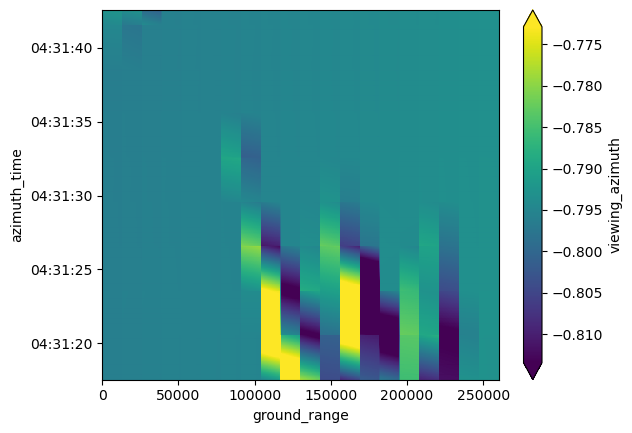

In [23]:
%%time
phi_i[::20, ::20].plot(robust=True)

CPU times: user 1min, sys: 7.47 s, total: 1min 8s
Wall time: 2min 8s


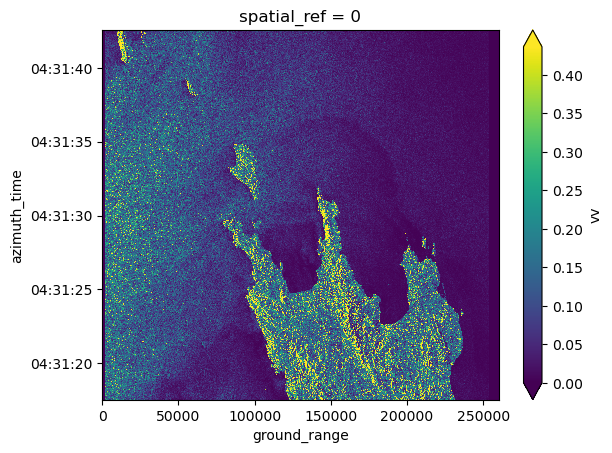

In [21]:
%%time
gamma0.vv[::20, ::20].plot(robust=True)

## Apply rectification

In [ ]:
%%time
grd = grd.assign_coords(dict(
    latitude=gcps_interp.latitude, 
    longitude=gcps_interp.longitude, 
))
grd

In [ ]:
%%time
grd_rect = rectify_dataset(grd, interp_methods="nearest", tile_size=2048)
grd_rect

In [ ]:
%%time
grd_rect = grd_rect.drop_vars(
    ["azimuth_time", "ground_range", "line", "pixel"]
)
grd_rect

In [ ]:
%%time
store = new_data_store("file", root="data")

In [ ]:
%%time
store.write_data(
    grd_rect.isel(lat=slice(0, 8192), lon=slice(0, 8192)),
    "sen1_rectified_sub.zarr",
    replace=True
)

In [ ]:
%%time
ds = store.open_data("sen1_rectified_sub.zarr")
ds

In [ ]:
%%time
ds.vv[::5, ::5].plot(vmax=300)